# 02 · Análisis univariado

**Pregunta que responde este notebook:** ¿cómo se distribuye cada variable por
separado, y qué hay que corregir antes de modelar?

### Una decisión metodológica antes de empezar

Todo el análisis univariado y bivariado (este notebook y el siguiente) se hace
**solo con los meses de referencia** (2024-01 a 2024-08), no con los 18 meses
juntos.

El motivo: el dataset contiene por diseño un cambio de distribución a partir de
2024-09. Si mezclásemos todos los meses, los histogramas mostrarían mezclas de
dos poblaciones distintas — bimodalidades que no son propiedades de la variable,
sino artefactos de haber apilado dos regímenes. Se concluiría, por ejemplo, que
`monthly_usage_gb` es bimodal, cuando en realidad es unimodal en cada régimen.

El estudio del cambio en el tiempo tiene su propio notebook (el 04), y es ahí
donde toca. Aquí se caracteriza la población tal como era cuando se entrenó el
modelo.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd

from src.config import CATEGORICAL_FEATURES, NUMERIC_FEATURES, REFERENCE_MONTHS
from src.data.generate_data import load_raw
from src.viz import INK_MUTED, SEQUENTIAL, SERIES, plt, set_style

set_style()

ref = load_raw(months=REFERENCE_MONTHS)
print(f"Periodo de referencia: {REFERENCE_MONTHS[0]} a {REFERENCE_MONTHS[-1]}")
print(f"{len(ref):,} filas")

Periodo de referencia: 2024-01 a 2024-08
20,700 filas


## Variables numéricas: distribuciones

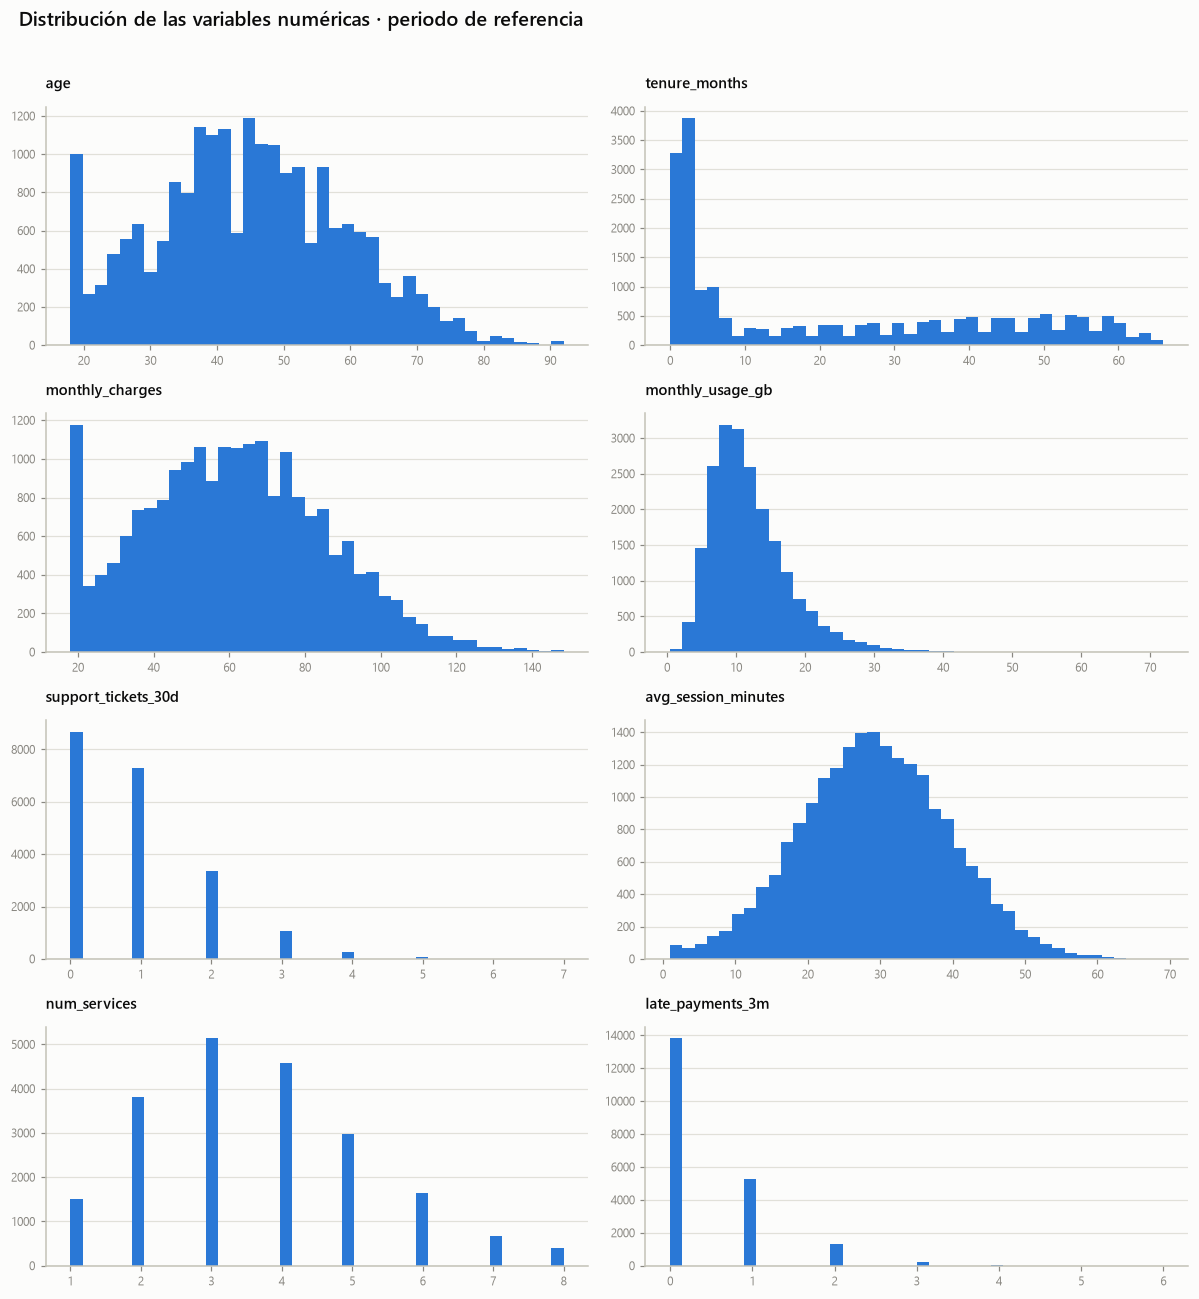

In [2]:
fig, axes = plt.subplots(4, 2, figsize=(11, 12))
for ax, col in zip(axes.ravel(), NUMERIC_FEATURES, strict=True):
    ax.hist(ref[col], bins=40, color=SERIES[0], edgecolor="none")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")
    ax.tick_params(labelsize=8)
fig.suptitle(
    "Distribución de las variables numéricas · periodo de referencia",
    x=0.02,
    ha="left",
    fontsize=13,
    fontweight="semibold",
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

Tres formas distintas, que piden tratamientos distintos:

- **Aproximadamente normales:** `age`, `monthly_charges`, `avg_session_minutes`.
- **Con cola derecha pronunciada:** `monthly_usage_gb`. Hay clientes que
  consumen varias veces la media.
- **De conteo, muy concentradas en cero:** `support_tickets_30d`,
  `late_payments_3m`, `num_services`. La mayoría de clientes no abre ningún
  ticket ni tiene impagos.

`tenure_months` merece un comentario aparte: su forma refleja la dinámica de la
base — clientes antiguos que sobreviven acumulando antigüedad, más una entrada
constante de clientes nuevos cerca de cero.

## Outliers

C:\Users\User\AppData\Local\Temp\ipykernel_27412\2594882255.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27412\2594882255.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27412\2594882255.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27412\2594882255.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
C:\Users\User\AppData\Local\Temp

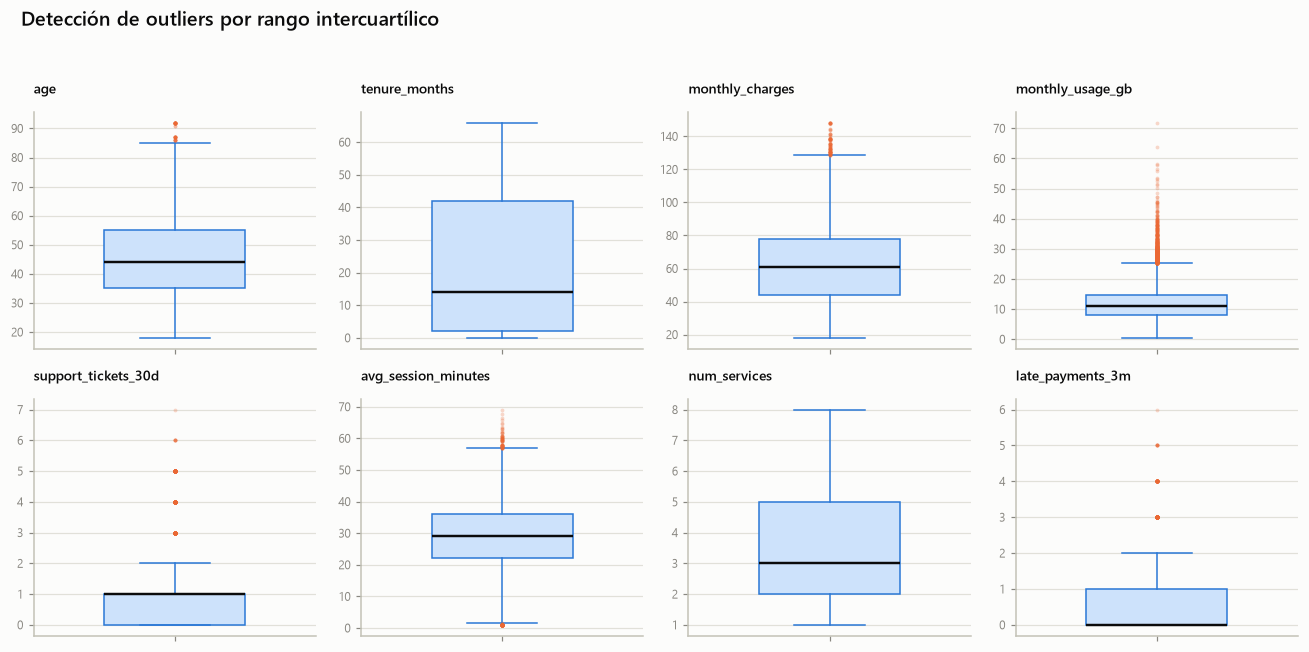

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, col in zip(axes.ravel(), NUMERIC_FEATURES, strict=True):
    bp = ax.boxplot(
        ref[col],
        vert=True,
        widths=0.5,
        patch_artist=True,
        flierprops={
            "marker": "o",
            "markersize": 2.5,
            "alpha": 0.25,
            "markerfacecolor": SERIES[1],
            "markeredgecolor": "none",
        },
        medianprops={"color": "#0b0b0b", "linewidth": 1.6},
        boxprops={"facecolor": "#cde2fb", "edgecolor": SERIES[0]},
        whiskerprops={"color": SERIES[0]},
        capprops={"color": SERIES[0]},
    )
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelbottom=False, labelsize=8)
fig.suptitle(
    "Detección de outliers por rango intercuartílico",
    x=0.02,
    ha="left",
    fontsize=13,
    fontweight="semibold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### ¿Cuánta masa hay realmente fuera de rango?

El boxplot marca muchos puntos, pero lo relevante es qué proporción de los datos
representan y hasta dónde llegan.

In [4]:
filas = []
for col in NUMERIC_FEATURES:
    q1, q3 = ref[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_sup = q3 + 1.5 * iqr
    fuera = (ref[col] > limite_sup).mean()
    filas.append(
        {
            "variable": col,
            "p50": ref[col].median(),
            "p99": ref[col].quantile(0.99),
            "max": ref[col].max(),
            "max/p99": round(ref[col].max() / max(ref[col].quantile(0.99), 1e-9), 2),
            "% sobre lím. sup.": round(fuera * 100, 2),
        }
    )
outliers = pd.DataFrame(filas).set_index("variable").round(2)
outliers

,p50,p99,max,max/p99,% sobre lím. sup.
variable,,,,,
age,44.00,78.00,92.00,1.18,0.21
tenure_months,14.00,63.00,66.00,1.05,0.00
monthly_charges,60.83,120.55,148.35,1.23,0.46
monthly_usage_gb,10.88,30.88,71.91,2.33,3.14
support_tickets_30d,1.00,4.00,7.00,1.75,6.63
avg_session_minutes,29.10,52.80,69.10,1.31,0.34
num_services,3.00,8.00,8.00,1.00,0.00
late_payments_3m,0.00,3.00,6.00,2.00,1.45


> **Conclusión.** El caso serio es `monthly_usage_gb`: el máximo está muy por
> encima del percentil 99. Son clientes reales, no errores de medición, así que
> eliminarlos sería tirar información. Pero dejarlos tal cual perjudica a la
> regresión logística, que es sensible a la escala de los valores extremos.
>
> **Decisión para la Fase 3:** **winsorización al percentil 1-99** de las
> variables numéricas, aplicada dentro del pipeline de sklearn. Recorta el efecto
> de los extremos sin descartar filas. Los modelos de árboles (XGBoost, LightGBM)
> son indiferentes a esto, pero el pipeline es común a los tres para que la
> comparación entre modelos sea justa.
>
> Los límites se aprenden **solo con los datos de entrenamiento** y se aplican a
> validación y a producción. Calcularlos sobre todo el dataset sería fuga de
> información.

## Variables categóricas: frecuencias

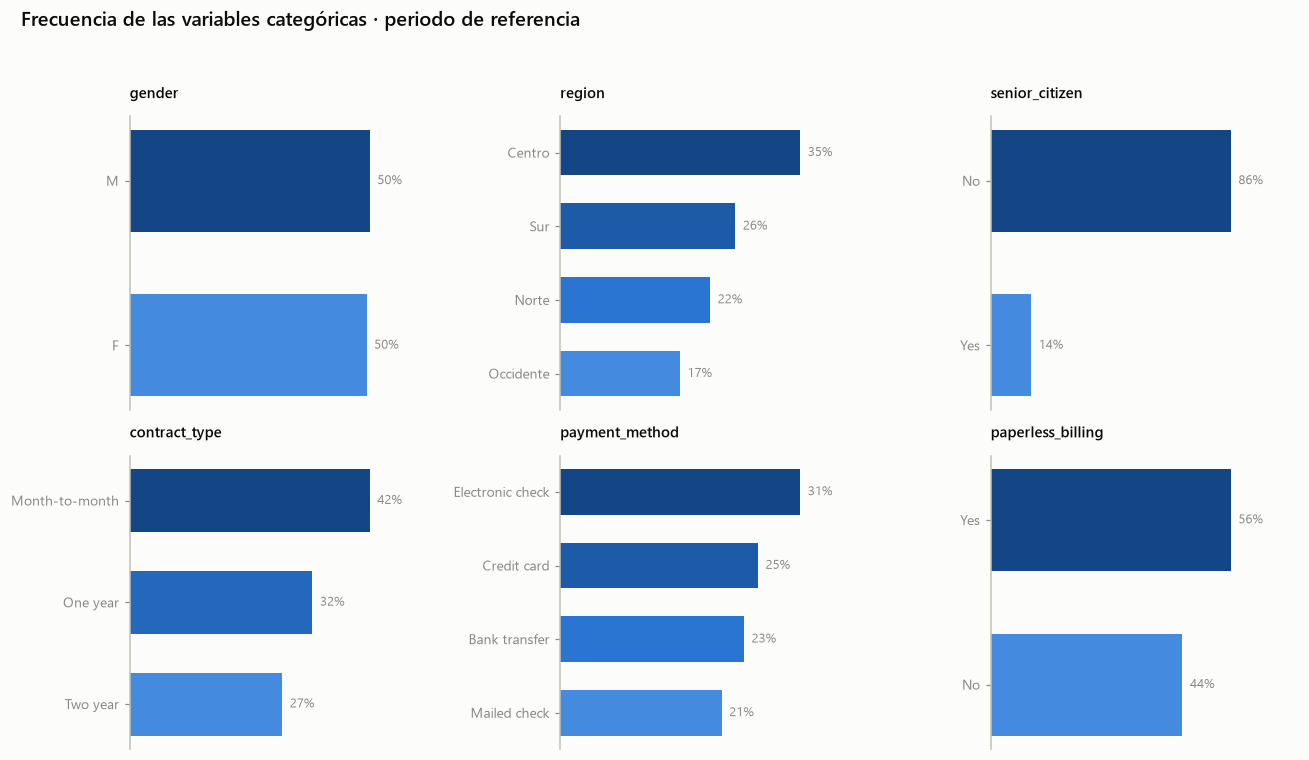

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.ravel(), CATEGORICAL_FEATURES, strict=True):
    frec = ref[col].value_counts(normalize=True).sort_values()
    colores = SEQUENTIAL(np.linspace(0.35, 0.85, len(frec)))
    ax.barh(frec.index.astype(str), frec.to_numpy(), color=colores, height=0.62)
    for y, v in enumerate(frec.to_numpy()):
        ax.annotate(
            f"{v:.0%}",
            xy=(v, y),
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
            fontsize=8.5,
            color=INK_MUTED,
        )
    ax.set_title(col, fontsize=10)
    ax.set_xlim(0, frec.max() * 1.28)
    ax.grid(False)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(bottom=False, labelbottom=False, labelsize=9)
fig.suptitle(
    "Frecuencia de las variables categóricas · periodo de referencia",
    x=0.02,
    ha="left",
    fontsize=13,
    fontweight="semibold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

> **Conclusión.** Ninguna categoría es tan rara como para tener que agruparla:
> la menos frecuente (`senior_citizen = Yes`) ronda el 16 %, con miles de
> observaciones detrás. Todas las variables son de cardinalidad baja (2 a 4
> niveles).
>
> **Decisión para la Fase 3:** **one-hot encoding** para todas, con
> `handle_unknown="ignore"`. Ese parámetro no es cosmético: en producción la API
> puede recibir una categoría que no existía al entrenar, y sin él el servicio
> devolvería un error 500 en vez de una predicción.

---
## Conclusiones de este notebook

| Hallazgo | Decisión para la Fase 3 |
|---|---|
| `monthly_usage_gb` con cola derecha larga | Winsorización p1–p99 dentro del pipeline, con límites aprendidos solo en train |
| Variables de conteo concentradas en cero | Se dejan como están; los modelos de árboles las manejan bien y la logística las recibe estandarizadas |
| Escalas muy dispares entre variables | `StandardScaler` para que la regresión logística no quede dominada por `monthly_charges` |
| Categóricas de cardinalidad baja, sin niveles raros | One-hot con `handle_unknown="ignore"` para no romper en producción ante categorías nuevas |

**Siguiente:** `03_analisis_bivariado.ipynb` — qué variables se relacionan
realmente con el churn, con contraste estadístico.